In [1]:
# Py Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import gaussian_kde

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Data
df = pd.read_csv("Final_Dataset.csv")

In [3]:
df.head()

,Gender,Age,BMI,Systolic_bp,Diastolic_bp,Cholesterol,Diabetes,Stress,Sleep,Mood,...,DietType,FoodDescription,Grams,Energy,Proteins,Carbs,Sugars,Fiber,Fat,Cholestrol
0,1.0,43.0,27.0,133.0,96.0,264.0,2.0,NaN,NaN,NaN,...,Non-combination food,"COFFEE, BREWED",300.0,3.0,0.36,0.00,0.00,0.0,0.06,0.0
1,1.0,43.0,27.0,133.0,96.0,264.0,2.0,NaN,NaN,NaN,...,Non-combination food,"WATER, TAP",240.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0
2,1.0,43.0,27.0,133.0,96.0,264.0,2.0,NaN,NaN,NaN,...,Non-combination food,"ICE CREAM, VANILLA, WITH ADDITIONAL INGREDIENTS",125.0,302.0,4.59,38.14,31.67,1.3,14.70,48.0
3,1.0,43.0,27.0,133.0,96.0,264.0,2.0,NaN,NaN,NaN,...,Non-combination food,"PIZZA, CHEESE, WITH VEGETABLES, FROM RESTAURAN...",208.0,510.0,20.26,63.29,7.09,4.4,19.54,31.0
4,1.0,43.0,27.0,133.0,96.0,264.0,2.0,NaN,NaN,NaN,...,Non-combination food,"RICE, WHITE, WITH PEAS AND CARROTS, FAT ADDED",240.0,308.0,6.45,55.79,2.60,3.0,5.88,0.0


Column|Info
---|----
Gender|Person Gender (1-Male, 2-Female)
Age(yrs), BMI(kg/m2), Bp(mmHg), Cholesterol(mg/dL)|Person Health Metrics
Diabetes|1-Yes, 2-No, 3-Borderline
Stress, Sleep, Mood|Person's Mental Health Questionary Status for last two weeks (0-Not at all, 1-Several days, 2-More than half the days, 3-Nearly every day, 7-Refused, 9-Don't know)
Snp_Seq|Person Genome Seq
Protein Fold Seq|Person Protein Fold Seq based on Snp_Seq
Occassion, DietType, FoodDescription | Food info taken for the day
Grams(weight of the food), Energy(kcal), Proteins(gm), Carbs(gm), Sugars(gm), Fiber(gm), Fat(gm), Cholestro(mg)| Nutrient Intakes for the day

* Col values rename for visuals

In [4]:
df.Gender.replace({1:'Male',2:'Female'}, inplace=True)
df.Diabetes.replace({1:'Yes',2:'No',3:'Borderline'}, inplace=True)
df.Stress.replace({0:'Not at all', 1:'Several days', 2:'More than half the days', 3:'Nearly every day', 
            7:'Refused', 9:"Don't know"}, inplace=True)
df.Sleep.replace({0:'Not at all', 1:'Several days', 2:'More than half the days', 3:'Nearly every day', 
            7:'Refused', 9:"Don't know"}, inplace=True)
df.Mood.replace({0:'Not at all', 1:'Several days', 2:'More than half the days', 3:'Nearly every day', 
            7:'Refused', 9:"Don't know"}, inplace=True)

In [5]:
df.head()

,Gender,Age,BMI,Systolic_bp,Diastolic_bp,Cholesterol,Diabetes,Stress,Sleep,Mood,...,DietType,FoodDescription,Grams,Energy,Proteins,Carbs,Sugars,Fiber,Fat,Cholestrol
0,Male,43.0,27.0,133.0,96.0,264.0,No,NaN,NaN,NaN,...,Non-combination food,"COFFEE, BREWED",300.0,3.0,0.36,0.00,0.00,0.0,0.06,0.0
1,Male,43.0,27.0,133.0,96.0,264.0,No,NaN,NaN,NaN,...,Non-combination food,"WATER, TAP",240.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0
2,Male,43.0,27.0,133.0,96.0,264.0,No,NaN,NaN,NaN,...,Non-combination food,"ICE CREAM, VANILLA, WITH ADDITIONAL INGREDIENTS",125.0,302.0,4.59,38.14,31.67,1.3,14.70,48.0
3,Male,43.0,27.0,133.0,96.0,264.0,No,NaN,NaN,NaN,...,Non-combination food,"PIZZA, CHEESE, WITH VEGETABLES, FROM RESTAURAN...",208.0,510.0,20.26,63.29,7.09,4.4,19.54,31.0
4,Male,43.0,27.0,133.0,96.0,264.0,No,NaN,NaN,NaN,...,Non-combination food,"RICE, WHITE, WITH PEAS AND CARROTS, FAT ADDED",240.0,308.0,6.45,55.79,2.60,3.0,5.88,0.0


**Individual**

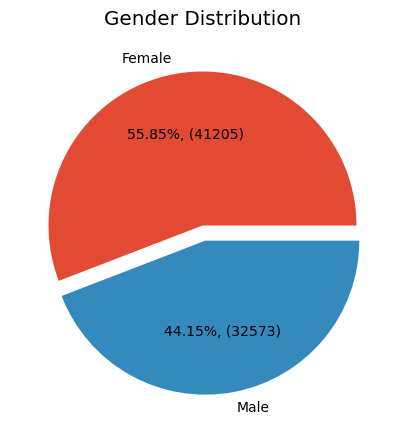

In [6]:
# Gender
classes = df['Gender'].value_counts().index
vals = df['Gender'].value_counts().values

plt.style.use("ggplot")
plt.figure(figsize=(5,5))
plt.pie(x = vals, labels = classes, autopct=lambda p:f'{p:.2f}%, ({p*sum(vals)/100 :.0f})', explode=[0,0.1]) 
# use explode=[0.5, 0.1, 0.5, 0.1, 0.5, 0.1] for seperate pies (number of values are number of classes)
plt.title("Gender Distribution")
plt.show()

Text(0.5, 1.0, 'Age Distribution')

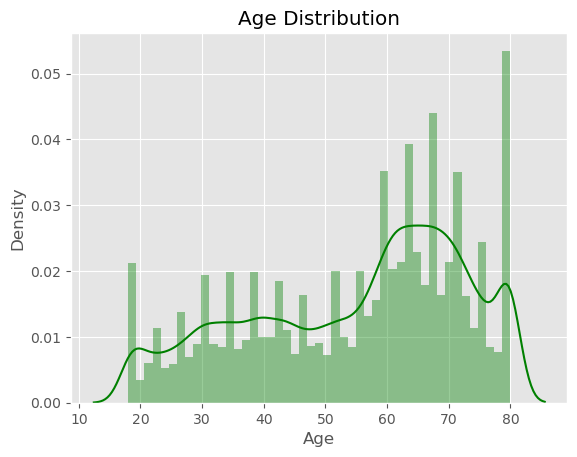

In [7]:
# Age
sns.distplot(df.Age, color='green')
plt.title("Age Distribution")

Text(0.5, 1.0, 'BMI Distribution')

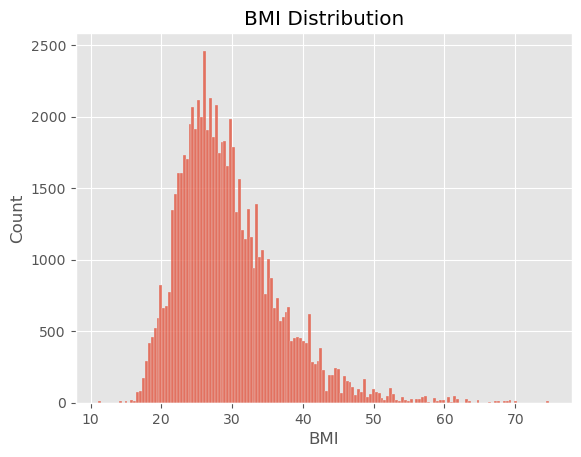

In [8]:
# BMI
sns.histplot(df.BMI)
plt.title("BMI Distribution")

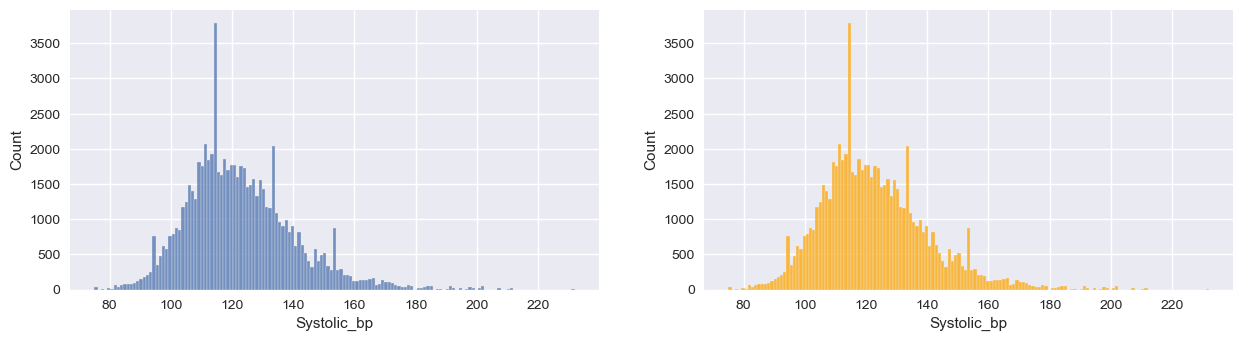

In [9]:
# BP
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(15,8))

plt.subplot(2, 2, 1)  # First subplot
# The figure will be in 2 row, 2 columns, first plot
sns.histplot(df.Systolic_bp)

plt.subplot(2, 2, 2)  # Second subplot
# The figure will be in 2 row, 2 columns, second plot
sns.histplot(df.Systolic_bp, color='orange')

plt.show()

Text(0.5, 1.0, 'Cholestrol Data Distribution')

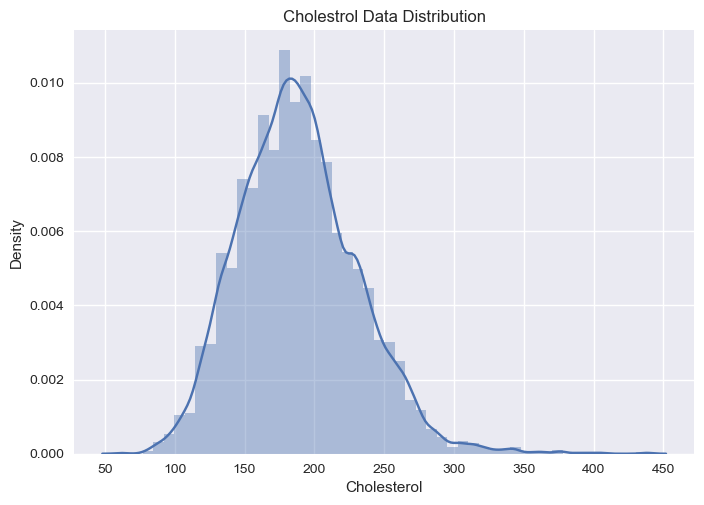

In [10]:
# Cholesterol
sns.distplot(df.Cholesterol)
plt.title("Cholestrol Data Distribution")

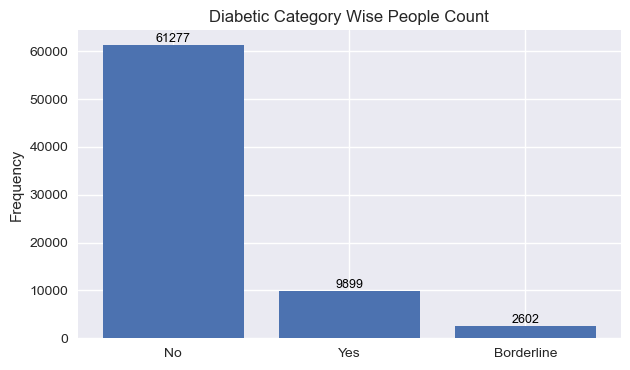

In [11]:
# Diabetes
classes = df['Diabetes'].value_counts().index
vals = df['Diabetes'].value_counts().values

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(7,4))
bars = plt.bar(classes, vals)
plt.title("Diabetic Category Wise People Count")
plt.ylabel("Frequency")
# Add count values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  # x-position
             height,                             # y-position
             str(height),                        # text
             ha='center', va='bottom', fontsize=9, color='black'
            )
plt.show()

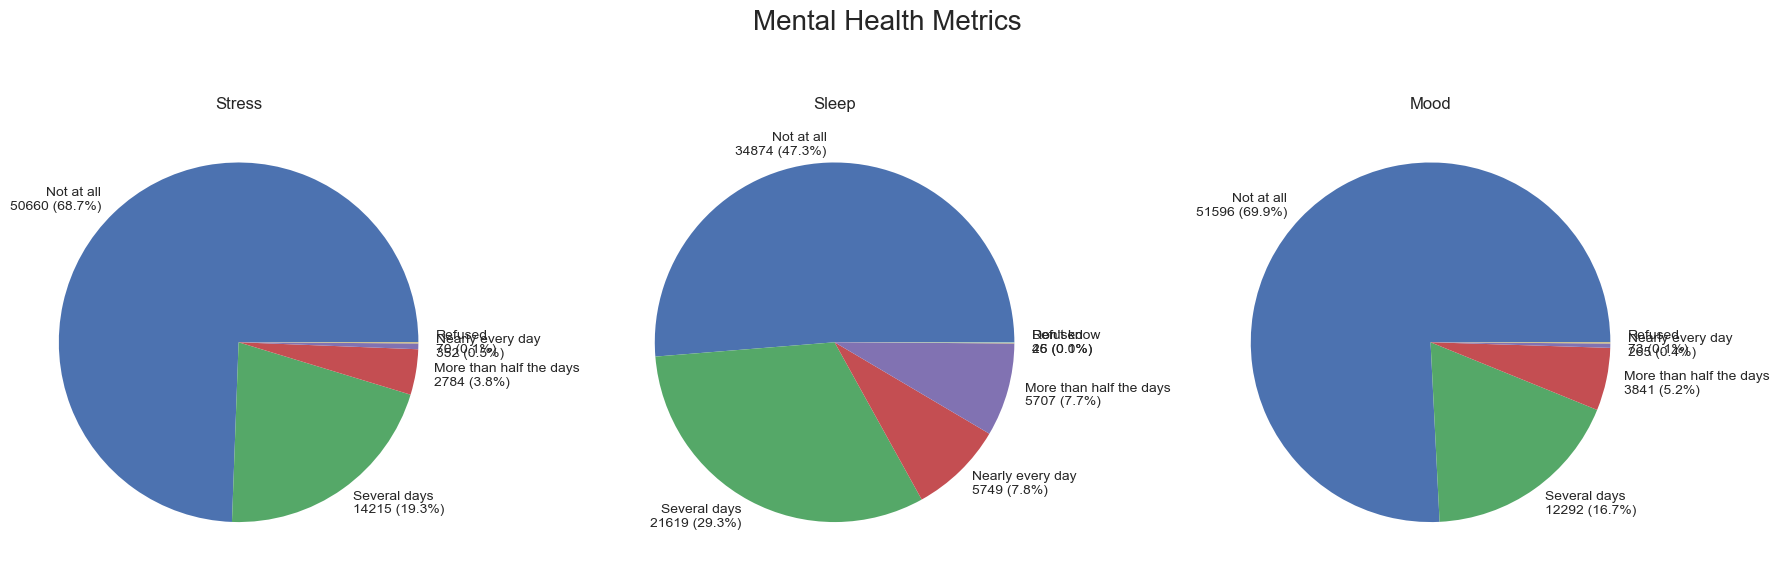

In [12]:
# Mental Health
cols = ['Stress', 'Sleep', 'Mood']

# Create subplot figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Mental Health Metrics", fontsize=20)

for ax, col in zip(axes, cols):
    counts = df[col].value_counts()
    
    # Labels with Count + Percentage
    labels = [f"{cat}\n{cnt} ({cnt/len(df)*100:.1f}%)" 
              for cat, cnt in counts.items()]
    
    # Pie chart
    ax.pie(counts, labels=labels)
    ax.set_title(col)

# Layout adjustment
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

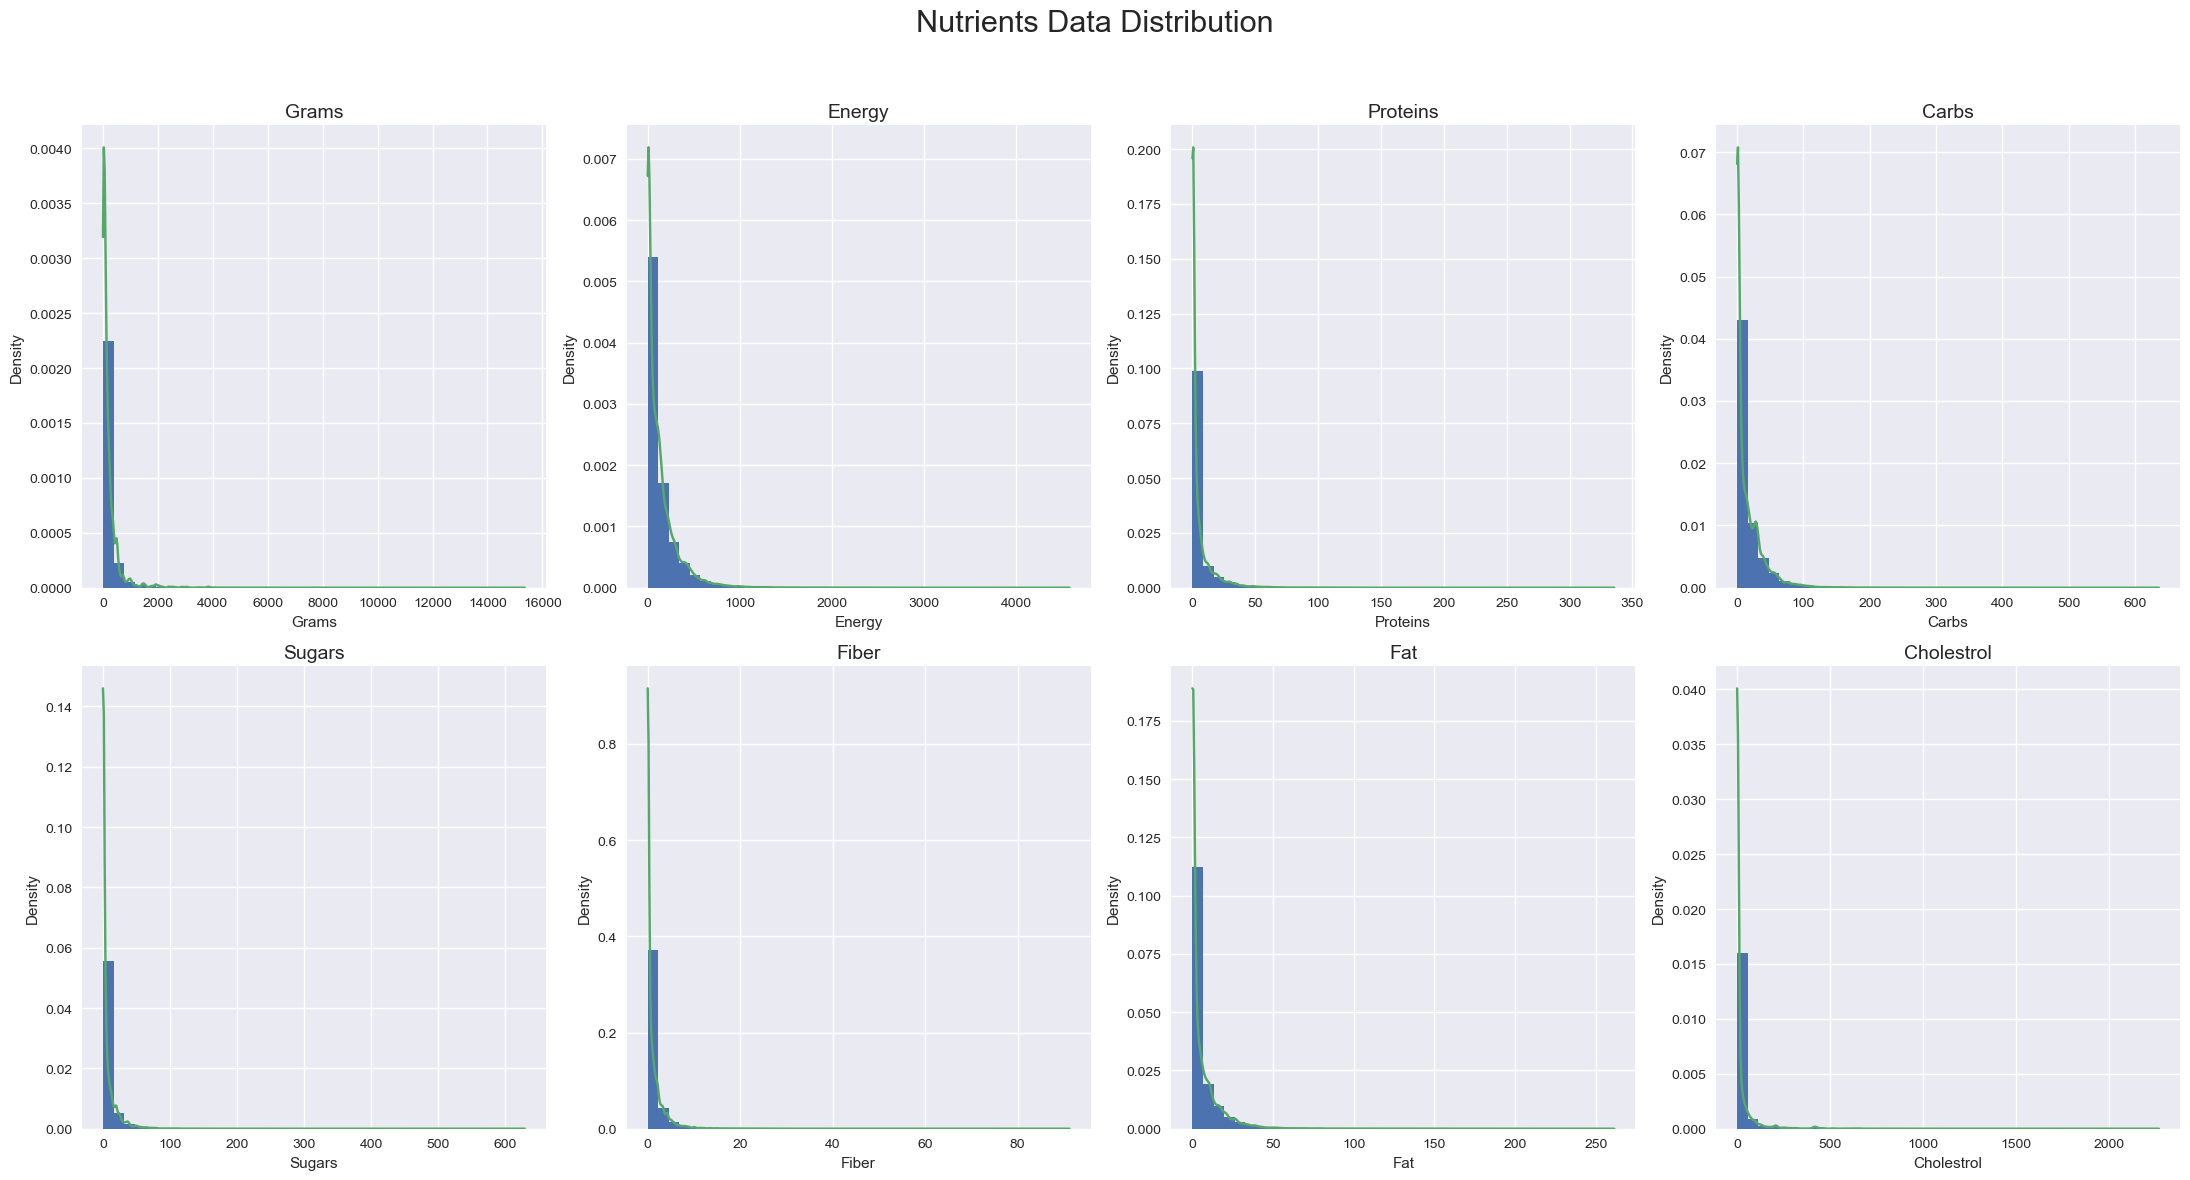

In [13]:
# Nutrients

# Nutrient columns
cols = ['Grams', 'Energy', 'Proteins', 'Carbs', 'Sugars', 'Fiber', 'Fat', 'Cholestrol']

# Create subplot grid
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
fig.suptitle("Nutrients Data Distribution", fontsize=22)

axes = axes.flatten()

for ax, col in zip(axes, cols):
    data = df[col].dropna()

    # Histogram
    ax.hist(data, bins=40, density=True)

    # KDE curve (manual using gaussian_kde)
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 500)
    ax.plot(x_range, kde(x_range))

    # Labels
    ax.set_title(col, fontsize=14)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Relations**

Text(0.5, 1.0, 'Heatmap Between Metrics vs Nutrients')

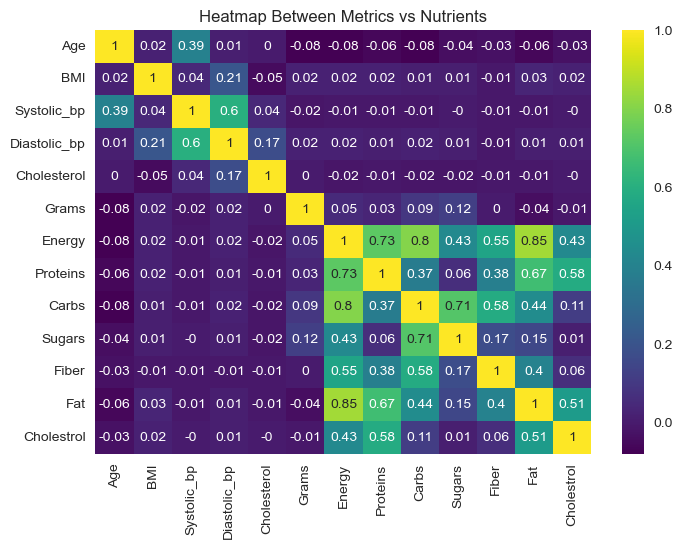

In [14]:
sns.heatmap(round(df.corr(numeric_only=True),2), annot=True, cmap='viridis')
plt.title("Heatmap Between Metrics vs Nutrients")

Text(0.5, 1.0, 'Gender wise Sugars Nutrient for Diabetes')

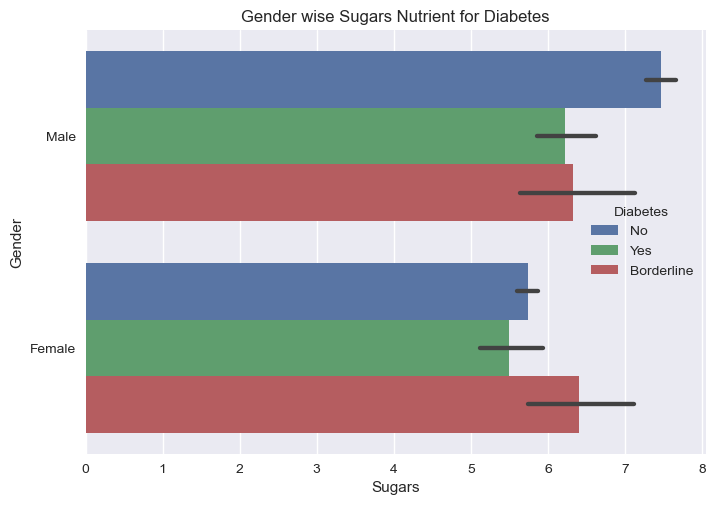

In [15]:
sns.barplot(df, y='Gender', x='Sugars', hue='Diabetes')
plt.title("Gender wise Sugars Nutrient for Diabetes")

Text(0.5, 1.0, 'Health Metrics vs Nutrients Gender wise Distribution')

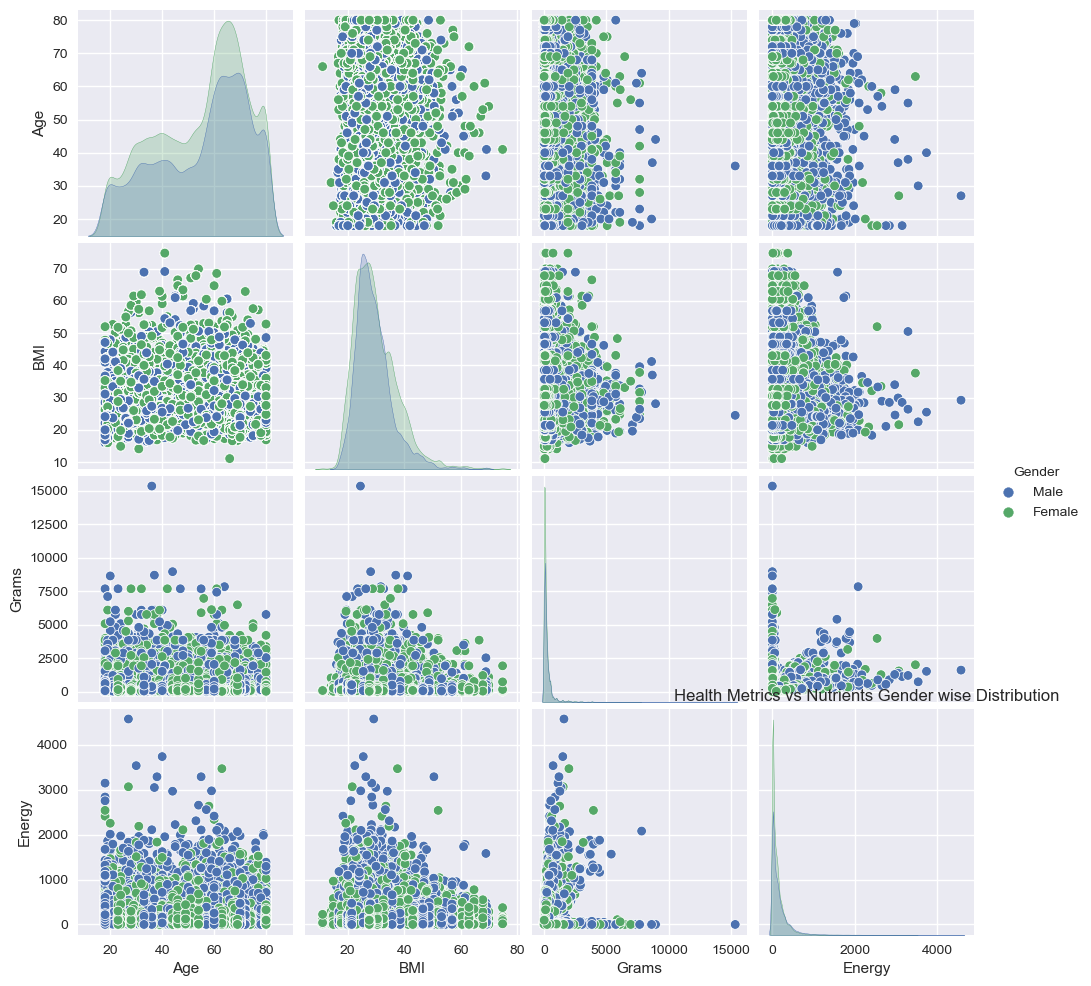

In [16]:
sns.pairplot(df[['Gender','Age','BMI','Grams','Energy', ]], hue='Gender')
plt.title("Health Metrics vs Nutrients Gender wise Distribution")